In [2]:
import kagglehub

# Download latest version
path1 = kagglehub.dataset_download("crawford/cat-dataset")

print("Path1 to dataset files:", path1)
import kagglehub

# Download latest version
path2 = kagglehub.dataset_download("yashdogra/dogs-dataset")

print("Path2 to dataset files:", path2)

Path1 to dataset files: /Users/jmdhanyakumar/.cache/kagglehub/datasets/crawford/cat-dataset/versions/2
Path2 to dataset files: /Users/jmdhanyakumar/.cache/kagglehub/datasets/yashdogra/dogs-dataset/versions/6


In [4]:
import kagglehub

# Download latest versions
cat_path = kagglehub.dataset_download("crawford/cat-dataset")
dog_path = kagglehub.dataset_download("yashdogra/dogs-dataset")

print("Cat dataset path:", cat_path)
print("Dog dataset path:", dog_path)

Cat dataset path: /Users/jmdhanyakumar/.cache/kagglehub/datasets/crawford/cat-dataset/versions/2
Dog dataset path: /Users/jmdhanyakumar/.cache/kagglehub/datasets/yashdogra/dogs-dataset/versions/6


In [6]:
import os
import shutil

# New combined dataset directory (auto create in current working directory)
base_dir = os.path.join(os.getcwd(), "pet_dataset")
cat_dest = os.path.join(base_dir, "cats")
dog_dest = os.path.join(base_dir, "dogs")

os.makedirs(cat_dest, exist_ok=True)
os.makedirs(dog_dest, exist_ok=True)

def copy_images(src, dest):
    for root, dirs, files in os.walk(src):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                src_file = os.path.join(root, file)
                dst_file = os.path.join(dest, file)

                # Avoid duplicate names
                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)

print("Copying cat images...")
copy_images(cat_path, cat_dest)

print("Copying dog images...")
copy_images(dog_path, dog_dest)

print("✅ Dataset successfully combined!")

Copying cat images...
Copying dog images...
✅ Dataset successfully combined!


In [8]:
DATASET_PATH = base_dir

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Folders inside:", os.listdir(DATASET_PATH))

Dataset exists: True
Folders inside: ['dogs', 'cats']


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 24459 images belonging to 2 classes.
Found 6114 images belonging to 2 classes.


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model created successfully!")

✅ Model created successfully!


/Users/jmdhanyakumar/task04/tfenv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 149s 195ms/step - accuracy: 0.7084 - loss: 0.5719 - val_accuracy: 0.7514 - val_loss: 0.5081
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 166s 217ms/step - accuracy: 0.7634 - loss: 0.4919 - val_accuracy: 0.7749 - val_loss: 0.4720
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 199s 259ms/step - accuracy: 0.8162 - loss: 0.4081 - val_accuracy: 0.8795 - val_loss: 0.3014
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 201s 263ms/step - accuracy: 0.8680 - loss: 0.3155 - val_accuracy: 0.8706 - val_loss: 0.3093
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 199s 260ms/step - accuracy: 0.8995 - loss: 0.2454 - val_accuracy: 0.9074 - val_loss: 0.2353



🐱 DOG vs CAT CLASSIFIER



📁 Enter image path (or 'quit'):  /Users/jmdhanyakumar/Desktop/dog.jpeg



✅ RESULT: DOG 
📊 Confidence: 100.0%
🔍 Compared with 24459 training images


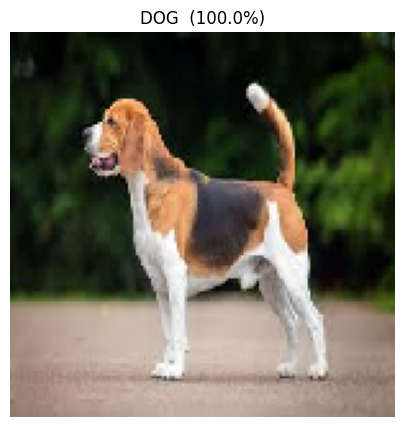


📁 Enter image path (or 'quit'):  /Users/jmdhanyakumar/Desktop/cat.jpeg



✅ RESULT: CAT 
📊 Confidence: 99.4%
🔍 Compared with 24459 training images


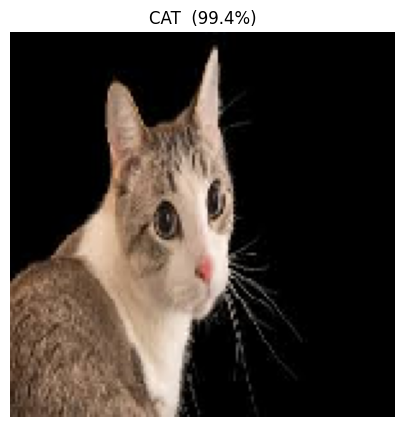


📁 Enter image path (or 'quit'):  quit


👋 Exiting...


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print("\n" + "="*60)
print("🐱 DOG vs CAT CLASSIFIER")
print("="*60)

while True:
    image_path = input("\n📁 Enter image path (or 'quit'): ").strip()
    
    if image_path.lower() == 'quit':
        print("👋 Exiting...")
        break
        
    if not os.path.exists(image_path):
        print("❌ File not found!")
        continue
    
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array, verbose=0)[0][0]
    
    if prediction > 0.5:
        label = "DOG "
        confidence = f"{prediction*100:.1f}%"
    else:
        label = "CAT "
        confidence = f"{(1-prediction)*100:.1f}%"
    
    print(f"\n✅ RESULT: {label}")
    print(f"📊 Confidence: {confidence}")
    print(f"🔍 Compared with {len(train_generator.classes)} training images")
    
    plt.figure(figsize=(6,5))
    plt.imshow(img)
    plt.title(f"{label} ({confidence})")
    plt.axis('off')
    plt.show()